# Analysis of Field Metaproteomics Data

This script is used to generate plots of metaproteomics data obtained from field samples and analyzed with DIA Mass Spectrometry on an Orbitrap Astral Mass Spectrometer. 

## Pre-Requisites
Please run your samples through the script 'merge_metaproteomics.ipynb' first. You should get an output file that contains all taxonomic (eggNOG) and biochemical (KEGG, KO, GO) data necessary.

## Step 1: Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS
from scipy.spatial.distance import pdist, squareform
import matplotlib as mpl
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
pio.renderers.default = "notebook"
import kaleido

#import cartopy.crs as ccrs
#import cartopy.feature as cfeature
#import cmocean

mpl.rcParams["font.family"] = "Arial"

## Step 2: Import Data, Normalize, Merge files
The output file from the previous step (merge_metaproteomics.ipynb) should have the name merged_prot_tax_ann_{sample_name}.csv. Please run this script first before importing data. 

Replace the filepath with the path to your metaproteomics datafile. 
If you have the amount of liters filtered through each filter associated with each sample, then please upload the metadata file with 

### Step 2.1 Import

In [2]:
# Main DIA metaproteomics table
df = pd.read_csv("../3_data/3_metaP/AE2520_Clio_57to60_Arianna260724db_final_report.pg_matrix_annotation_report.csv", sep=",")
print(df)

# Dataframe metadata contains metadata information on how many liters were filtered, lat, long, salinity, temperature, and fluorescence data. 
metadata = pd.read_csv("../3_data/3_metaP/station_liters.csv", sep=",")

# Function to convert "DD MM.MMM" to decimal degrees
def dm_to_dd(coord):
    deg, minutes = coord.split()
    return float(deg) + float(minutes)/60

metadata["lat"] = metadata["lat"].apply(dm_to_dd)
metadata["long"] = metadata["long"].apply(dm_to_dd)
metadata["long"] = -metadata["long"].abs()

print(metadata)

                               query_id     domain          phylum  \
0      megahit_UW100_lg_k111_1020468.p1  Eukaryota       Alveolata   
1      megahit_UW100_lg_k111_1047863.p1  Eukaryota    Opisthokonta   
2      megahit_UW100_lg_k111_1096247.p2  Eukaryota        Hacrobia   
3      megahit_UW100_lg_k111_1098721.p1  Eukaryota    Opisthokonta   
4      megahit_UW100_lg_k111_1120325.p1  Eukaryota       Alveolata   
...                                 ...        ...             ...   
62882         transect_small_9875218.p9   Bacteria  Proteobacteria   
62883         transect_small_9897981.p1          -  Pseudomonadota   
62884         transect_small_9904127.p1   Bacteria  Proteobacteria   
62885         transect_small_9911886.p2   Bacteria   Cyanobacteria   
62886         transect_small_9969823.p3   Bacteria  Proteobacteria   

                     class             order            family  \
0                Dinophyta       Dinophyceae     Dinophyceae_X   
1                  Metazoa 

### Step 2.2 Sample Info + Merge with Metadata

In [3]:
# sample columns are columns containing "clio"
sample_cols = [c for c in df.columns if "Clio" in c]

def parse_sample(col):
    """
    Extract the sample number from the end of the Clio filename.
    Example:
    ..._Clio_206.raw -> 206
    """
    return col.split("_")[-1].replace(".raw", "")

# Create dataframe with the full filename and sample number
sample_info = pd.DataFrame({
    "sample": [os.path.basename(c) for c in sample_cols],
    "sample_number": [parse_sample(c) for c in sample_cols]
})

# Make sure merge keys have the same type
metadata["sample"] = metadata["sample"].astype(str)
sample_info["sample_number"] = sample_info["sample_number"].astype(str)

# Merge metadata with sample filenames
metadata = metadata.merge(
    sample_info,
    left_on="sample",
    right_on="sample_number",
    how="left"
)

# remove dublicate merge key
metadata = metadata.drop(columns=["sample_number"])

print(metadata)

    sample_x     station  liters        lat       long  depth  \
0         73  clio057_02    77.1  31.357450 -64.776917   15.0   
1         74  clio057_02    77.1  31.357450 -64.776917  110.0   
2         75  clio057_02    81.5  31.357450 -64.776917  110.0   
3         76  clio057_02   143.9  31.357450 -64.776917  150.0   
4         77  clio057_02   172.5  31.357450 -64.776917  250.0   
..       ...         ...     ...        ...        ...    ...   
139      212  clio060_51    36.2  39.767033 -70.884017   54.9   
140      213  clio060_51    31.8  39.767033 -70.884017  162.6   
141      214  clio060_51    37.3  39.767033 -70.884017   43.2   
142      215  clio060_51    67.3  39.767033 -70.884017  100.0   
143      216  clio060_51    85.2  39.767033 -70.884017  200.0   

                          sample_y  
0     260702_AE2520_02_Clio_73.raw  
1     260702_AE2520_02_Clio_74.raw  
2     260702_AE2520_02_Clio_75.raw  
3     260702_AE2520_02_Clio_76.raw  
4     260702_AE2520_02_Clio_77.raw

### 2.3 Normalize Protein Normalized peak area / Liter seawater filtered

In [4]:
# Sample columns = columns containing "Clio"
sample_cols = [col for col in df.columns if "Clio" in col]

# Map sample filename -> liters
liters_map = metadata.set_index("sample_x")["liters"].to_dict()

# Normalize each sample column by liters filtered
df_norm = df.copy()

for col in sample_cols:
    sample_number = col.split("_")[-1].replace(".raw", "")
    df_norm[col] = df_norm[col] / liters_map[sample_number]

print(df_norm.head())

                           query_id     domain        phylum       class  \
0  megahit_UW100_lg_k111_1020468.p1  Eukaryota     Alveolata   Dinophyta   
1  megahit_UW100_lg_k111_1047863.p1  Eukaryota  Opisthokonta     Metazoa   
2  megahit_UW100_lg_k111_1096247.p2  Eukaryota      Hacrobia  Haptophyta   
3  megahit_UW100_lg_k111_1098721.p1  Eukaryota  Opisthokonta     Metazoa   
4  megahit_UW100_lg_k111_1120325.p1  Eukaryota     Alveolata  Ciliophora   

              order         family                 genus           species  \
0       Dinophyceae  Dinophyceae_X        Dinophyceae_XX       Alexandrium   
1        Arthropoda       Hexapoda               Insecta           Nasonia   
2  Prymnesiophyceae   Prymnesiales  Chrysochromulinaceae  Chrysochromulina   
3          Cnidaria     Cnidaria_X              Anthozoa      Nematostella   
4      Spirotrichea   Oligotrichia         Strombidiidae       Strombidium   

  taxonomy_source taxonomy_conflict  ...  \
0         phylodb             

## Step 3: For UW ONLY: Plot stations against map, chla and temperature

In [39]:
metadata_uw_clio = pd.read_csv("../3_data/3_metaP/AE2520_UW_metadata.csv", sep=",")
print(metadata_uw_clio)

# Function to convert "DD MM.MMM" to decimal degrees
def dm_to_dd(coord):
    deg, minutes = coord.split()
    return float(deg) + float(minutes)/60

metadata_uw_clio["lat"] = metadata_uw_clio["lat"].apply(dm_to_dd)
metadata_uw_clio["long"] = metadata_uw_clio["long"].apply(dm_to_dd)
metadata_uw_clio["long"] = -metadata_uw_clio["long"].abs()

print(metadata_uw_clio)

fig = px.scatter_map(
    metadata_uw_clio,
    lat="lat",
    lon="long",
    #color="temperature",       # seawater temperature color
    #size="fluorescence",       # dot size
    hover_name="station_id",
    size_max=30,
    color_continuous_scale="thermal",  # good for temperature
    opacity=0.85,
    zoom=4
)

fig.update_layout(
    mapbox=dict(
        style="stamen-terrain",
        center=dict(
            lat=metadata_uw_clio["lat"].mean(),
            lon=metadata_uw_clio["long"].mean()
        )),
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(pad=0, r=2, t=2, b=2, l=2),
    font=dict(
        family="Arial",
        size=18,
        color="black"
    )
)

#fig.update_layout(coloraxis_colorbar_title_text="Temperature (°C)")
#fig.write_image(
#     '../5_figures/Fig0_stationmap.pdf',
#     width=2400,
#     height=1600)
# fig.write_html("../5_figures/Fig0_stationmap.html", include_plotlyjs="cdn")
fig.show()

   station_id        lat       long
0         UW1  31 67.933  64 17.227
1         UW2  32 66.770  64 28.443
2         UW3  31 68.537   64 35.69
3         UW4  31 65.275  64 40.978
4         UW5  31 64.078  64 45.808
..        ...        ...        ...
66       UW74  39 76.815  70 88.292
67    clio057  31 21.447  64 46.615
68    clio058  36 05.141  65 41.356
69    clio059  35 49.716  65 43.122
70    clio060  39 46.022  70 53.041

[71 rows x 3 columns]
   station_id        lat       long
0         UW1  32.132217 -64.287117
1         UW2  33.112833 -64.474050
2         UW3  32.142283 -64.594833
3         UW4  32.087917 -64.682967
4         UW5  32.067967 -64.763467
..        ...        ...        ...
66       UW74  40.280250 -71.471533
67    clio057  31.357450 -64.776917
68    clio058  36.085683 -65.689267
69    clio059  35.828600 -65.718700
70    clio060  39.767033 -70.884017

[71 rows x 3 columns]


## Step 4: Data Overview - NMDS

In [6]:
X = df_norm[sample_cols].T.fillna(0)

# Bray-Curtis distance
dist = squareform(pdist(X, metric="braycurtis"))

nmds = MDS(
    n_components=2,
    metric=False,
    dissimilarity="precomputed",
    random_state=42,
    max_iter=3000
)

coords = nmds.fit_transform(dist)

nmds_df = pd.DataFrame(coords, columns=["NMDS1", "NMDS2"])
nmds_df["sample"] = sample_cols

nmds_df = nmds_df.join(
    sample_info.set_index("sample"),
    on="sample"
)

# Extract sample number from the full file path
nmds_df["sample_number"] = (
    nmds_df["sample"]
    .str.extract(r"Clio_(\d+)\.raw")[0]
    .astype(int)
)

# Make sure metadata sample numbers are integers too
metadata["sample_x"] = metadata["sample_x"].astype(int)

# Merge NMDS coordinates with metadata
nmds_df = nmds_df.merge(
    metadata,
    left_on="sample_number",
    right_on="sample_x",
    how="left"
)

# Remove duplicate metadata sample column
nmds_df = nmds_df.drop(columns=["sample_x", "sample_y"])

print("Stress:", nmds.stress_)
print(nmds_df)



/Users/fadimestemmer/miniconda3/envs/AE2504_metaP/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning:

The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.

/Users/fadimestemmer/miniconda3/envs/AE2504_metaP/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning:

The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.

/Users/fadimestemmer/miniconda3/envs/AE2504_metaP/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning:

The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.

/Users/fadimestemmer/miniconda3/envs/AE2504_metaP/lib/python3.13/site-packages/sklearn/manifold/_mds.py:779: FutureWarning:

Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.



Stress: 0.06694885528980041
        NMDS1     NMDS2                                             sample  \
0    0.403454  0.849014  C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_7...   
1    0.005867  0.637279  C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_7...   
2    0.002688  0.423751  C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_7...   
3   -0.293765  0.082676  C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_7...   
4   -0.456815 -0.343531  C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_7...   
..        ...       ...                                                ...   
138  0.270082 -0.427679  C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_2...   
139  0.295481  0.154606  C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_2...   
140  0.311442  0.033020  C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_2...   
141  0.276426  0.148823  C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_2...   
142  0.091284 -0.384168  C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_2...   

     sample_number     station  lit

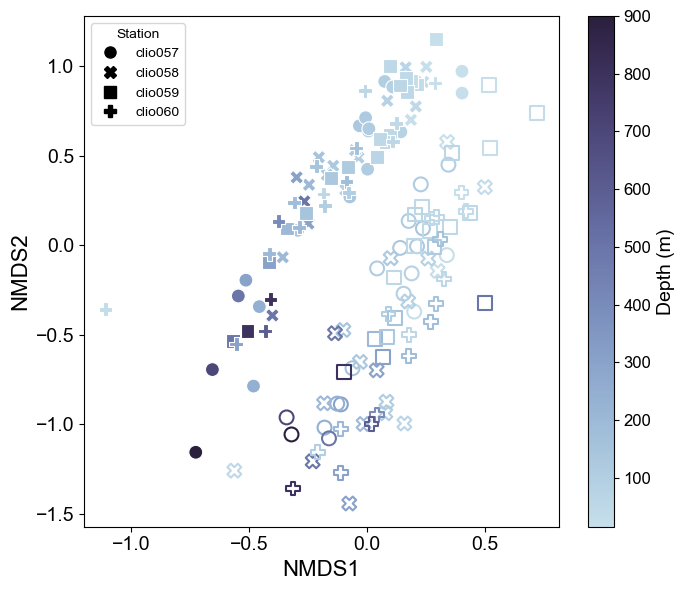

In [7]:
# Extract Clio station number only
nmds_df["clio_station"] = (
    nmds_df["station"]
    .str.extract(r"(clio\d+)", expand=False)
)

# Extract filter size
nmds_df["filter"] = (
    nmds_df["station"]
    .str.extract(r"_(\d+)$", expand=False)
)

palette = sns.color_palette("ch:s=.25,rot=-.25", as_cmap=True)

plt.figure(figsize=(7, 6))

ax = plt.gca()

# Same normalization as your original plot
norm = mpl.colors.Normalize(
    vmin=nmds_df["depth"].min(),
    vmax=nmds_df["depth"].max()
)

# Get the same marker mapping Seaborn would use for clio_station
stations = nmds_df["clio_station"].unique()
markers = ["o", "X", "s", "P", "D", "^", "v", "<", ">"]
marker_map = {
    station: markers[i % len(markers)]
    for i, station in enumerate(stations)
}

# Plot each filter separately
for filter_size in ["02", "51"]:

    subset = nmds_df[nmds_df["filter"] == filter_size]

    for station, group in subset.groupby("clio_station"):

        # Keep the SAME depth palette
        colors = palette(norm(group["depth"].values))

        if filter_size == "02":
            # Filled marker
            ax.scatter(
                group["NMDS1"],
                group["NMDS2"],
                c=colors,
                marker=marker_map[station],
                s=100,
                edgecolors="white",
                linewidths=0.8
            )

        else:
            # Outline-only marker
            ax.scatter(
                group["NMDS1"],
                group["NMDS2"],
                facecolors="none",
                edgecolors=colors,
                marker=marker_map[station],
                s=100,
                linewidths=1.5
            )

ax.tick_params(axis="both", labelsize=14)
ax.set_xlabel("NMDS1", fontsize=16)
ax.set_ylabel("NMDS2", fontsize=16)

# Continuous depth colorbar
sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=palette
)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Depth (m)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Station legend
legend_handles = []

for station in stations:
    legend_handles.append(
        mpl.lines.Line2D(
            [],
            [],
            marker=marker_map[station],
            linestyle="None",
            markerfacecolor="black",
            markeredgecolor="black",
            markersize=8,
            label=station
        )
    )

ax.legend(
    handles=legend_handles,
    title="Station"
)

plt.tight_layout()

plt.savefig(
    "../5_figures/3_metaP/Fig1_NMDS.pdf",
    format="pdf"
)

plt.show()

## Step 5: Analyze Microbial Community Composition 

In [46]:
def select_tax(df_norm, tax_level='domain', samples=None):

    if samples is None:
        samples = sample_cols

    tax_df = (
        df_norm
        .groupby(tax_level)[samples]
        .sum()
        .T
    )

    tax_order = (
        df_norm
        .groupby(tax_level)[samples]
        .sum()
        .sum(axis=1)
        .sort_values(ascending=False)
        .index
    )

    tax_df_rel = tax_df.div(tax_df.sum(axis=1), axis=0)

    return tax_df_rel[tax_order]

In [64]:
def plot_community(df_norm, tax_level='domain', dives=None, filtersize=None, metadata=metadata, save_path=None):

    metadata_plot = metadata.copy()

    if dives is not None:
        if not isinstance(dives, list):
            dives = [dives]

        dive_numbers = metadata_plot["station"].str.extract(
            r"clio0*(\d+)_"
        )[0].astype(float)

        metadata_plot = metadata_plot[
            dive_numbers.isin([int(d) for d in dives])
        ].copy()

    if filtersize is not None:
        metadata_plot = metadata_plot[
            metadata_plot["station"].str.endswith(f"_{str(filtersize)}")
        ].copy()

    metadata_plot["sample_y"] = metadata_plot["sample_y"].apply(
        lambda x: os.path.basename(x) if pd.notna(x) else x
    )

    selected_samples = metadata_plot["sample_y"].dropna().tolist()

    sample_cols_plot = [
        col for col in sample_cols
        if os.path.basename(col) in selected_samples
    ]

    tax_df_rel = select_tax(
        df_norm,
        tax_level=tax_level,
        samples=sample_cols_plot
    )

    plot_df = tax_df_rel.copy()
    plot_df["sample_y"] = plot_df.index.map(os.path.basename)

    plot_df = plot_df.reset_index(drop=True).merge(
        metadata_plot[["sample_x", "station", "depth", "sample_y"]],
        on="sample_y",
        how="left"
    )

    plot_df["dive"] = plot_df["station"].str.extract(
        r"clio0*(\d+)_"
    )[0]

    plot_df["filter"] = plot_df["station"].str.extract(
        r"_(\d+)$"
    )[0]

    plot_df["Sample"] = (
        "Clio " + plot_df["dive"]
        + " | " + plot_df["filter"] + " µm"
        + " | " + plot_df["depth"].round(1).astype(str) + " m"
    )

    plot_df["dive_num"] = plot_df["dive"].astype(int)

    plot_df = plot_df.sort_values(
        ["dive_num", "depth"]
    ).reset_index(drop=True)

    plot_long = plot_df.melt(
        id_vars=["sample_y", "sample_x", "station", "depth", "Sample"],
        var_name=tax_level,
        value_name="Fractional Sum"
    )

    fig = px.bar(
        plot_long,
        x="Sample",
        y="Fractional Sum",
        color=tax_level,
        color_discrete_sequence=px.colors.qualitative.Safe,
        barmode="stack",
        template="plotly_white",
        width=1800,
        height=800,
        labels={
            "Sample": "Sample",
            "Fractional Sum": "Fractional Sum",
            tax_level: tax_level.capitalize()
        }
    )

    fig.update_traces(marker_line_width=0)

    fig.update_xaxes(
        showline=True,
        linewidth=1,
        linecolor="black",
        mirror=True,
        tickangle=90
    )

    fig.update_yaxes(
        showline=True,
        linewidth=1,
        linecolor="black",
        mirror=True,
        range=[0, 1]
    )

    fig.update_layout(
        font_family="Arial",
        font_size=18,
        autosize=True
    )

    if save_path is not None:
        os.makedirs(save_path, exist_ok=True)

        filename_base = f"community_{tax_level}"

        if dives is not None:
            filename_base += "_dives" + "_".join(map(str, dives))

        if filtersize is not None:
            filename_base += f"_filter{filtersize}"

        fig.write_html(
            os.path.join(save_path, filename_base + ".html"),
            include_plotlyjs="cdn"
        )

        fig.write_image(
            os.path.join(save_path, filename_base + ".pdf")
        )

    return fig

In [52]:
plot_community(df_norm, metadata=metadata, tax_level='genus', save_path='../5_figures/3_metaP/community/')  # change to domain/class/order/family/genus/species

In [63]:
plot_community(df_norm, metadata=metadata, filtersize='02', tax_level='domain', save_path='../5_figures/3_metaP/community_filters/') 

In [75]:
plot_community(df_norm, metadata=metadata, dives='57', filtersize='51', tax_level='genus', save_path='../5_figures/3_metaP/community_dives/') 
plot_community(df_norm, metadata=metadata, dives='58', filtersize='51', tax_level='genus', save_path='../5_figures/3_metaP/community_dives/')
plot_community(df_norm, metadata=metadata, dives='59', filtersize='51', tax_level='genus', save_path='../5_figures/3_metaP/community_dives/') 
plot_community(df_norm, metadata=metadata, dives='60', filtersize='51', tax_level='genus', save_path='../5_figures/3_metaP/community_dives/')
#domain/class/order/family/genus/species
plot_community(df_norm, metadata=metadata, dives='57', filtersize='02', tax_level='genus', save_path='../5_figures/3_metaP/community_dives/') 
plot_community(df_norm, metadata=metadata, dives='58', filtersize='02', tax_level='genus', save_path='../5_figures/3_metaP/community_dives/')
plot_community(df_norm, metadata=metadata, dives='59', filtersize='02', tax_level='genus', save_path='../5_figures/3_metaP/community_dives/') 
plot_community(df_norm, metadata=metadata, dives='60', filtersize='02', tax_level='genus', save_path='../5_figures/3_metaP/community_dives/')

## Step 6: Protein groups

In [5]:
metadata_02 = metadata[metadata["station"].str.endswith(f"_{str('02')}")].copy()
metadata_51 = metadata[metadata['station'].str.endswith(f"_{str(51)}")].copy()
print(metadata_02, metadata_51, df_norm)

    sample_x     station  liters        lat       long  depth  \
0         73  clio057_02    77.1  31.357450 -64.776917   15.0   
1         74  clio057_02    77.1  31.357450 -64.776917  110.0   
2         75  clio057_02    81.5  31.357450 -64.776917  110.0   
3         76  clio057_02   143.9  31.357450 -64.776917  150.0   
4         77  clio057_02   172.5  31.357450 -64.776917  250.0   
..       ...         ...     ...        ...        ...    ...   
121      194  clio060_02    36.2  39.767033 -70.884017   54.9   
122      195  clio060_02    31.8  39.767033 -70.884017  162.6   
123      196  clio060_02    37.3  39.767033 -70.884017   43.2   
124      197  clio060_02    67.3  39.767033 -70.884017  100.0   
125      198  clio060_02    85.2  39.767033 -70.884017  200.0   

                          sample_y  
0     260702_AE2520_02_Clio_73.raw  
1     260702_AE2520_02_Clio_74.raw  
2     260702_AE2520_02_Clio_75.raw  
3     260702_AE2520_02_Clio_76.raw  
4     260702_AE2520_02_Clio_77.raw

In [22]:
def protein_line(df_norm, metadata=metadata, KEGG=None, KO=None, OG=None, GO=None, PFAM=None, total=None, dive=None, save_path=None):

    df = df_norm.copy()
    metadata = metadata.copy()

    # Filter to specific dive
    if dive is not None:
        metadata = metadata[metadata["station"] == dive].copy()

    # Sort by depth if plotting a dive, otherwise by station
    if dive is not None:
        metadata = metadata.sort_values("depth")
    else:
        metadata = metadata.sort_values("station")

    # Match metadata sample_y (filename) to df columns
    sample_map = {
        os.path.basename(col): col
        for col in df.columns
    }

    sorted_samples = [
        sample_map[s]
        for s in metadata["sample_y"]
        if s in sample_map
    ]

    # Filter proteins
    if KEGG is not None:
        df = df[df["KEGG"] == KEGG]
    if KO is not None:
        df = df[df["KO"] == KO]
    if OG is not None:
        df = df[df["best_OG_desc"].str.contains(OG, na=False)]
    if PFAM is not None:
        df = df[df["PFAMs"] == PFAM]
    if GO is not None:
        df = df[df["go_terms"].str.contains(GO, na=False)]

    # Keep only sorted sample columns
    protein_df = df[sorted_samples].T

    # Match samples to metadata
    metadata_lookup = metadata.set_index("sample_y")
    sample_names = [os.path.basename(x) for x in protein_df.index]

    protein_df["station"] = [
        metadata_lookup.loc[x, "station"] for x in sample_names
    ]
    protein_df["depth"] = [
        metadata_lookup.loc[x, "depth"] for x in sample_names
    ]

    # Choose x-axis
    if dive is not None:
        protein_df = protein_df.sort_values("depth")
        x_values = protein_df["depth"]
        x_title = "Depth [m]"
    else:
        protein_df = protein_df.sort_values("station")
        x_values = protein_df["station"]
        x_title = "Station"

    if total == "yes":
        total_values = protein_df.select_dtypes(include="number").sum(axis=1)

    # Plot
    fig = go.Figure()
    colors = px.colors.sample_colorscale(
        "BuPu",
        [i / max(len(protein_df.columns) - 1, 1) for i in range(len(protein_df.columns))]
    )

    # Only plot protein columns, not metadata columns
    protein_columns = [
        col for col in protein_df.columns
        if col not in ["station", "depth"]
    ]

    for i, protein in enumerate(protein_columns):
        fig.add_trace(
            go.Scatter(
                x=x_values,
                y=protein_df[protein],
                mode="lines+markers",
                name=protein,
                line=dict(color=colors[i % len(colors)])
            )
        )

    if total == "yes":
        fig.add_trace(
            go.Scatter(
                x=x_values,
                y=total_values,
                mode="lines+markers",
                name="Total",
                line=dict(color="black", width=4),
            )
        )

    fig.update_layout(
        template="plotly_white",
        width=1200,
        height=700,
        xaxis_title=x_title,
        yaxis_title="Amount of protein [µg L<sup>-1</sup>]",
        legend_title="Protein Name",
        font_family="Arial",
        font_size=18,
        autosize=True
    )

    if save_path is not None:
        os.makedirs(save_path, exist_ok=True)

        filename_base = "lineplot"
        if dive is not None:
            filename_base += f"_{dive}"

        html_file = os.path.join(save_path, filename_base + ".html")
        pdf_file = os.path.join(save_path, filename_base + ".pdf")

        fig.write_html(html_file, include_plotlyjs="cdn")
        fig.write_image(pdf_file)

    return fig

In [26]:
def protein_line_profile(
    df_norm,
    metadata=metadata,
    KEGG=None,
    KO=None,
    OG=None,
    GO=None,
    PFAM=None,
    total=None,
    dive=None,
    max_depth=None,
    save_path=None
):

    df = df_norm.copy()
    metadata = metadata.copy()

    # Filter to specific dive
    if dive is not None:
        metadata = metadata[metadata["station"] == dive].copy()

    # Sort by depth if plotting a dive, otherwise by station
    if dive is not None:
        metadata = metadata.sort_values("depth")
    else:
        metadata = metadata.sort_values("station")

    # Match metadata sample_y (filename) to df columns
    sample_map = {
        os.path.basename(col): col
        for col in df.columns
    }

    sorted_samples = [
        sample_map[s]
        for s in metadata["sample_y"]
        if s in sample_map
    ]

    # Filter proteins
    if KEGG is not None:
        df = df[df["KEGG"] == KEGG]
    if KO is not None:
        df = df[df["KO"] == KO]
    if OG is not None:
        df = df[df["best_OG_desc"].str.contains(OG, na=False)]
    if PFAM is not None:
        df = df[df["PFAMs"] == PFAM]
    if GO is not None:
        df = df[df["go_terms"].str.contains(GO, na=False)]

    # Keep only sorted sample columns
    protein_df = df[sorted_samples].T

    # Match samples to metadata
    metadata_lookup = metadata.set_index("sample_y")
    sample_names = [os.path.basename(x) for x in protein_df.index]

    protein_df["station"] = [
        metadata_lookup.loc[x, "station"] for x in sample_names
    ]

    protein_df["depth"] = [
        metadata_lookup.loc[x, "depth"] for x in sample_names
    ]

    # --------------------------------------------------
    # DEPTH PROFILE
    # --------------------------------------------------
    if dive is not None:

        protein_df = protein_df.sort_values("depth")

        depth_values = protein_df["depth"]

        # Optional depth cutoff
        if max_depth is not None:
            mask = depth_values <= max_depth
            protein_df = protein_df.loc[mask]
            depth_values = protein_df["depth"]

        y_values = depth_values

        x_title = "Amount of protein [µg L<sup>-1</sup>]"
        y_title = "Depth [m]"

    # --------------------------------------------------
    # STATION PLOT
    # --------------------------------------------------
    else:

        protein_df = protein_df.sort_values("station")

        x_values = protein_df["station"]

        x_title = "Station"
        y_title = "Amount of protein [µg L<sup>-1</sup>]"

    # Total protein
    if total == "yes":
        total_values = protein_df.select_dtypes(include="number").sum(axis=1)

    # Protein columns only
    protein_columns = [
        col for col in protein_df.columns
        if col not in ["station", "depth"]
    ]

    # Colors
    colors = px.colors.sample_colorscale(
        "BuPu",
        [
            i / max(len(protein_columns) - 1, 1)
            for i in range(len(protein_columns))
        ]
    )

    # Plot
    fig = go.Figure()

    for i, protein in enumerate(protein_columns):

        if dive is not None:
            # Depth profile: protein abundance = x, depth = y
            fig.add_trace(
                go.Scatter(
                    x=protein_df[protein],
                    y=depth_values,
                    mode="lines+markers",
                    name=protein,
                    line=dict(color=colors[i % len(colors)])
                )
            )

        else:
            # Normal station plot
            fig.add_trace(
                go.Scatter(
                    x=x_values,
                    y=protein_df[protein],
                    mode="lines+markers",
                    name=protein,
                    line=dict(color=colors[i % len(colors)])
                )
            )

    # Total
    if total == "yes":

        if dive is not None:
            fig.add_trace(
                go.Scatter(
                    x=total_values,
                    y=depth_values,
                    mode="lines+markers",
                    name="Total",
                    line=dict(color="black", width=4),
                )
            )

        else:
            fig.add_trace(
                go.Scatter(
                    x=x_values,
                    y=total_values,
                    mode="lines+markers",
                    name="Total",
                    line=dict(color="black", width=4),
                )
            )

    # Layout
    fig.update_layout(
        template="plotly_white",
        width=1200,
        height=700,
        xaxis_title=x_title,
        yaxis_title=y_title,
        legend_title="Protein Name",
        font_family="Arial",
        font_size=18,
        autosize=True
    )

    # Put surface at top and depth increasing downward
    if dive is not None:
        fig.update_yaxes(
            autorange="reversed",
            range=[max_depth, 0] if max_depth is not None else None
        )

    # Save
    if save_path is not None:

        os.makedirs(save_path, exist_ok=True)

        filename_base = "lineplot"

        if dive is not None:
            filename_base += f"_{dive}"

        if max_depth is not None:
            filename_base += f"_0-{max_depth}m"

        html_file = os.path.join(save_path, filename_base + ".html")
        pdf_file = os.path.join(save_path, filename_base + ".pdf")

        fig.write_html(html_file, include_plotlyjs="cdn")
        fig.write_image(pdf_file)

    return fig

In [28]:
protein_line_profile(df_norm, metadata=metadata_02, max_depth=900, GO='GO:0008233', total='yes', dive='clio057_02', save_path='../5_figures/3_metaP/proteins/proteases_GO0008233/')
protein_line_profile(df_norm, metadata=metadata_51, max_depth=900, GO='GO:0008233', total='yes', dive='clio057_51', save_path='../5_figures/3_metaP/proteins/proteases_GO0008233/')
protein_line_profile(df_norm, metadata=metadata_02, max_depth=900, GO='GO:0008233', total='yes', dive='clio058_02', save_path='../5_figures/3_metaP/proteins/proteases_GO0008233/')
protein_line_profile(df_norm, metadata=metadata_51, max_depth=900, GO='GO:0008233', total='yes', dive='clio058_51', save_path='../5_figures/3_metaP/proteins/proteases_GO0008233/')
protein_line_profile(df_norm, metadata=metadata_02, max_depth=900, GO='GO:0008233', total='yes', dive='clio059_02', save_path='../5_figures/3_metaP/proteins/proteases_GO0008233/')
protein_line_profile(df_norm, metadata=metadata_51, max_depth=900, GO='GO:0008233', total='yes', dive='clio059_51', save_path='../5_figures/3_metaP/proteins/proteases_GO0008233/')
protein_line_profile(df_norm, metadata=metadata_02, max_depth=900, GO='GO:0008233', total='yes', dive='clio060_02', save_path='../5_figures/3_metaP/proteins/proteases_GO0008233/')
protein_line_profile(df_norm, metadata=metadata_51, max_depth=900, GO='GO:0008233', total='yes', dive='clio060_51', save_path='../5_figures/3_metaP/proteins/proteases_GO0008233/')

In [114]:
print(metadata_02.index)
print(df_norm.columns)

#protein_line(df_norm, sample_info, filtersize='02', EC='3.4', save_path='../figures/OSM2026/lineplot_VolumeNorm/')

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,
        46,  47,  48,  49,  50,  51,  52,  53,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89, 108, 109,
       110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123,
       124, 125],
      dtype='int64')
Index(['query_id', 'domain', 'phylum', 'class', 'order', 'family', 'genus',
       'species', 'taxonomy_source', 'taxonomy_conflict',
       ...
       'C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_206.raw',
       'C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_207.raw',
       'C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_208.raw',
       'C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_209.raw',
       'C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_210.raw',
       'C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_211.raw',
       'C:/DATA/AE2520_clio_uw/260702_AE2520_02_Clio_

In [34]:
protein_line(df_norm, sample_info, filtersize='51', EC='3.4', save_path='../figures/OSM2026/lineplot_VolumeNorm/')

/var/folders/hb/hntvhz5j0j15vb_5h21tbhph0000gn/T/ipykernel_20588/4168333434.py:64: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



In [38]:
protein_line(df_norm, sample_info, filtersize='02', OG='secretion', save_path='../figures/OSM2026/lineplot_VolumeNorm/')

In [20]:
def protein_tax_line(df_norm, sample_info,
                     protein_name,
                     tax_level="Genus",
                     filtersize=None, save_path=None):

    df = df_norm.copy()
    si = sample_info.copy()

    #Sort Stations
    si = si.sort_values("UW_num")

    if filtersize is not None:
        si = si[si["filter"] == filtersize]

    sorted_samples = si.index.tolist()

    # Filter one protein
    mask_pfam = df["PFAMs"].str.contains(protein_name, na=False)
    mask_og = df["best_OG_desc"].str.contains(protein_name, na=False)
    mask_ec = df["EC"].str.startswith(protein_name, na=False)
    mask_name = df["Preferred_name"] == protein_name
    
    if mask_pfam.any():
        df = df[mask_pfam]
    
    if mask_ec.any():
        df = df[mask_ec]
    
    elif mask_og.any():
        df = df[mask_og]
    
    elif mask_name.any():
        df = df[mask_name]
    
    else:
        print("No data found for this protein.")
        return

    # Group one protein
    if tax_level not in df.columns:
        raise ValueError(f"{tax_level} not found in dataframe columns")

    # --- TOTAL protein per sample (across all taxa & all matching rows) ---
    total_per_sample = df[sorted_samples].sum(axis=0)
    
    print("\nTotal protein per sample:")
    for sample in sorted_samples:
        print(sample, total_per_sample[sample])

    unique_taxa = df[tax_level].unique()
    palette = px.colors.qualitative.Safe

    color_map = {
        tax: palette[i % len(palette)]
        for i, tax in enumerate(unique_taxa)
    }

    # Create mapping dataframe for plotting
    sample_meta = si.loc[sorted_samples].copy()
    
    if filtersize is None:
        # Aggregate per station (multiple filters per station)
        
        # Add station + UW number to total
        total_df = pd.DataFrame({
            "value": total_per_sample.values,
            "station": sample_meta["station"].values,
            "UW_num": sample_meta["UW_num"].values
        })
    
        total_df = (
            total_df
            .groupby(["station", "UW_num"])
            .sum()
            .reset_index()
            .sort_values("UW_num")
        )
    
        x_values = total_df["station"].values
        total_values = total_df["value"].values
    
    else:
        # Single filter → just relabel & sort
        sample_meta = sample_meta.sort_values("UW_num")
    
        x_values = sample_meta["station"].values
        total_values = total_per_sample.loc[sample_meta.index].values
    
    # Plot each row separately
    fig = go.Figure()

    for idx, row in df.iterrows():
        # each taxon = a row in all the samples. Checks the taxon in row[taxlevel column specified in fuction argument]
        taxon = row[tax_level] 
        # y_values are all rows summed for each sample. Here the rows already only contain the specified proteins.
        y_values = row[sorted_samples].values

        fig.add_trace(
            go.Scatter(
                x=x_values,
                y=y_values,
                mode='lines+markers',
                name=f"{row['Preferred_name']} | {taxon}",
                line=dict(color=color_map[taxon]),
                legendgroup=taxon,
                showlegend=True
            )
        )

        fig.update_layout(
            template="plotly_white",
            width=1200,
            height=700,
            xaxis_title="Station",
            yaxis_title="Amount of protein in µg L <sup>-1</sup>",
            legend_title= f"Protein Name | {tax_level}",
            title=f"{protein_name}",
            font_family="Arial",
            font_size=18
        )
    
    fig.add_trace(
        go.Scatter(
            x=x_values,
            y=total_per_sample.values,
            mode='lines+markers',
            name="Total",
            line=dict(color="black", width=4),
        )
    )

        # Save files
    if save_path is not None:
        os.makedirs(save_path, exist_ok=True)
    
        filename_base = f'lineplot_{protein_name}'
        if filtersize:                
            filename_base += f"_{filtersize}"
    
        html_file = os.path.join(save_path, filename_base + ".html")
        pdf_file = os.path.join(save_path, filename_base + ".pdf")
    
        # Interactive HTML
        fig.write_html(html_file, include_plotlyjs="cdn")
    
        # Static PDF
        fig.write_image(pdf_file)

    return fig

In [26]:
protein_tax_line(df_norm, sample_info,
                 protein_name="urtA",
                 tax_level="domain",
                 filtersize="02")


Total protein per sample:
13_UW28_02 1977284.965675057
19_UW70_02 3775033.442940038
35_UW77_02 1166645.1317254175
41_UW89_02 1863072.738028169
49_UW96_02 1760874.3
55_UW99_02 652539.68
61_UW103_02 1223316.1510791369


In [47]:
protein_tax_line(df_norm, sample_info,
                 protein_name="fecA",
                 tax_level="domain",
                 filtersize="02")


Total protein per sample:
13_UW28_02 0.0
19_UW70_02 7141.644100580271
35_UW77_02 5071.224489795918
41_UW89_02 9292.112676056338
49_UW96_02 14724.517857142857
55_UW99_02 0.0
61_UW103_02 9879.604316546762


## Total intensity normalization
STEP 1: Divide each protein normalized peak area by sum of normalized peak area per sample. This will give us value from 0-1.


STEP 2: Normalized peak area by total intensity normalization mapping to total amount of protein extracted. 1 = amount of µg protein extracted per sample

STEP 3: Multiply fractional value (STEP 1) by the total amount of protein to get amount of protein in µg

STEP 4: Divide by L seawater filtered through the filter for the amount of protein in µg per L (concentration) 

In [12]:
# If samples look uniform then use maxLFQ if not use normal intensity. 
total_protein = pd.read_csv('../data/metaP/final_output/total_protein.csv').sort_values("Dataset")
print(total_protein)

# STEP 1 - Total intensity Normalization
df_norm_TI = df.copy()
for col in sample_cols:
    df_norm_TI[col] = df[col] / df[col].sum(axis=0)

print(df_norm_TI.head())

# STEP 2+3+4 - protein amount + Liter seawater filtered
df_final = df_norm_TI.copy()

for col in sample_cols:
    total_ug = total_protein.loc[total_protein['Dataset'] == col, 'total_protein_ug'].values[0]
    print(total_ug)

    volume_L = total_protein.loc[total_protein["Dataset"] == col, "volume_filtered_filtersize"].values[0]
    print(volume_L)

    concentration = total_ug / volume_L
    print(concentration)

    df_final[col] = (df_final[col]* concentration)

### DOUBLE CHECK : Sum of columns * volume_L should give us the total_protein_ug
for col in sample_cols:

    total_ug = total_protein.loc[
        total_protein['Dataset'] == col,
        'total_protein_ug'
    ].values[0]

    volume_L = total_protein.loc[
        total_protein['Dataset'] == col,
        'volume_filtered_filtersize'
    ].values[0]

    reconstructed_total = df_final[col].sum() * volume_L

    print(col)
    print("Original total ug:", total_ug)
    print("Reconstructed total ug:", reconstructed_total)
    print("Difference:", total_ug - reconstructed_total)
    print("-----")

print(df_final.head())

        Dataset  protein_conc_ugul  total_protein_ug  volume_filtered  \
0    13_UW28_02           0.085513             7.696             42.1   
1    19_UW70_02           0.108895             9.801             22.7   
2    25_UW73_51           0.128380            11.554             52.2   
3    33_UW77_51           0.036243             3.262             53.9   
4    35_UW77_02           0.100989             9.089             53.9   
5    38_UW85_51           0.108346             9.751             47.5   
6    40_UW89_51           0.017114             1.540             35.5   
7    41_UW89_02           0.099517             8.957             35.5   
8    48_UW96_51           0.036243             3.262             56.0   
9    49_UW96_02           0.123062            11.076             56.0   
10   54_UW99_51           0.120119            10.811             32.5   
11   55_UW99_02           0.159849            14.386             32.5   
12  60_UW103_51           0.070087             6.30

### NMDS

In [32]:
X = df_final[sample_cols].T

# Bray–Curtis distance
dist = squareform(pdist(X, metric="braycurtis"))

nmds = MDS(n_components=2, metric=False, dissimilarity="precomputed",
           random_state=42, max_iter=3000)
coords = nmds.fit_transform(dist)

nmds_df = pd.DataFrame(coords, columns=["NMDS1", "NMDS2"])
nmds_df["sample"] = sample_cols
nmds_df = nmds_df.join(sample_info, on="sample")

palette = sns.color_palette('viridis')
print("Stress:", nmds.stress_)

Stress: 0.049649617240761404


/Users/fadimestemmer/miniconda3/envs/AE2504_metaP/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning:

The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.

/Users/fadimestemmer/miniconda3/envs/AE2504_metaP/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning:

The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.

/Users/fadimestemmer/miniconda3/envs/AE2504_metaP/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning:

The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.

/Users/fadimestemmer/miniconda3/envs/AE2504_metaP/lib/python3.13/site-packages/sklearn/manifold/_mds.py:779: FutureWarning:

Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.



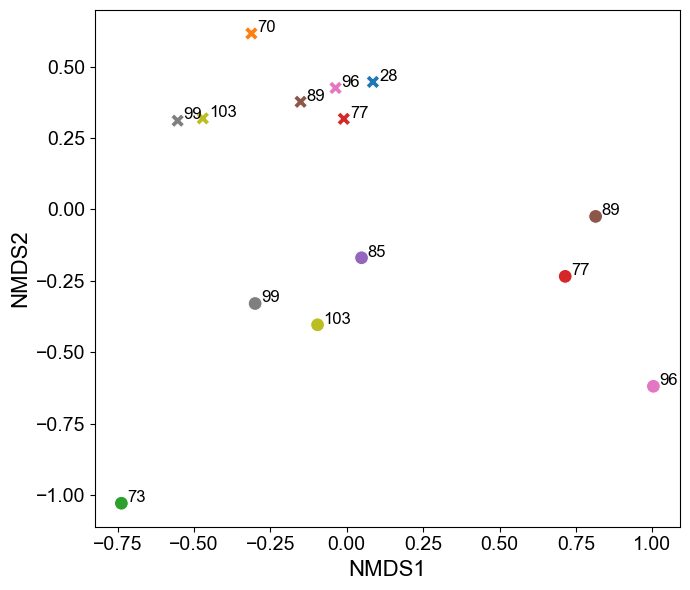

In [7]:
# Extract numeric station ID
nmds_df["UW_num"] = (
    nmds_df["station"]
    .str.replace("UW", "", regex=False)
    .astype(int)
)

station_order = (
    nmds_df
    .sort_values("UW_num")["station"]
    .unique()
)


nmds_df["station"] = pd.Categorical(
    nmds_df["station"],
    categories=station_order,
    ordered=True
)

plt.figure(figsize=(7,6))

ax = sns.scatterplot(
    data=nmds_df,
    x="NMDS1",
    y="NMDS2",
    hue="station", 
    style = "filter", 
    s=100,
    legend=False
)

dx, dy = 0.02, 0.02  # tweak as needed

for _, row in nmds_df.iterrows():
    ax.text(
        row["NMDS1"] + dx,
        row["NMDS2"] + dy,
        row["UW_num"], 
        fontsize=12,
        ha="left",
        va="center"
    )

ax.tick_params(axis="both", labelsize=14)
ax.set_xlabel("NMDS1", fontsize=16)
ax.set_ylabel("NMDS2", fontsize=16)
plt.tight_layout()
plt.savefig('../figures/FigS2_NMDS_TotalIntensity_Normalized.pdf', format='pdf')
plt.show()

### Taxonomy

In [105]:
plot_community(df_final, tax_level='supergroup', filtersize=None)  # change to domain/supergroup/division/class/order/family/genus/species

In [106]:
plot_community(df_final, tax_level='supergroup', filtersize='51')  # change to domain/supergroup/division/class/order/family/genus/species

In [107]:
plot_community(df_final, tax_level='supergroup', filtersize='02')  # change to domain/supergroup/division/class/order/family/genus/species

### Line plots

In [19]:
protein_line(df_final, sample_info, filtersize=None, EC='3.4', total ='yes', save_path='../figures/OSM2026/New/')

/var/folders/hb/hntvhz5j0j15vb_5h21tbhph0000gn/T/ipykernel_55947/4252022695.py:68: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



In [20]:
protein_line(df_final, sample_info, filtersize='02', EC='3.4', total = 'yes', save_path='../figures/OSM2026/New/')

/var/folders/hb/hntvhz5j0j15vb_5h21tbhph0000gn/T/ipykernel_55947/4252022695.py:68: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



In [21]:
protein_line(df_final, sample_info, filtersize='51', EC='3.4', total = 'yes', save_path='../figures/OSM2026/New/')

/var/folders/hb/hntvhz5j0j15vb_5h21tbhph0000gn/T/ipykernel_55947/4252022695.py:68: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



In [22]:
protein_tax_line(df_final, sample_info,
                 protein_name="urtA",
                 tax_level="supergroup",
                 filtersize=None, 
                 save_path='../figures/OSM2026/New/')


Total protein per sample:
13_UW28_02 0.0033922169012126652
19_UW70_02 0.01061468245325235
25_UW73_51 0.00016274344776771494
35_UW77_02 0.0015513915789347732
33_UW77_51 3.4701419843151596e-05
38_UW85_51 0.0003799265486804981
41_UW89_02 0.002429968343278119
40_UW89_51 5.305208648138799e-05
49_UW96_02 0.0025222317321989553
48_UW96_51 1.9436373748021093e-05
55_UW99_02 0.001294414629058457
54_UW99_51 0.00014932666067312406
61_UW103_02 0.0015383877376678508
60_UW103_51 0.00011923203724277


In [18]:
protein_tax_line(df_final, sample_info,
                 protein_name="3.4",
                 tax_level="supergroup",
                 filtersize=None, save_path='../figures/OSM2026/New/')


Total protein per sample:
13_UW28_02 0.002991238809503757
19_UW70_02 0.009062623445158364
25_UW73_51 0.004147133658411455
35_UW77_02 0.0035861039999525177
33_UW77_51 0.0008230637553212643
38_UW85_51 0.0034127612679726686
41_UW89_02 0.005472774576680961
40_UW89_51 0.0007152502984191126
49_UW96_02 0.003781076775452874
48_UW96_51 0.000521686954006154
55_UW99_02 0.0073538937978361255
54_UW99_51 0.005082260276168282
61_UW103_02 0.006350561729865277
60_UW103_51 0.004263206626996447


In [21]:
protein_tax_line(df_final, sample_info,
                 protein_name="type I secretion",
                 tax_level="class",
                 filtersize=None, save_path='../figures/OSM2026/New/')


Total protein per sample:
13_UW28_02 0.0001078911324374713
19_UW70_02 0.00034474027278251577
25_UW73_51 0.0
35_UW77_02 3.284602899835272e-05
33_UW77_51 3.8028282304866776e-06
38_UW85_51 3.173682994534851e-05
41_UW89_02 5.935531711026444e-05
40_UW89_51 6.131654500012295e-06
49_UW96_02 6.579456988358852e-05
48_UW96_51 6.391318809476944e-06
55_UW99_02 9.311857714674554e-05
54_UW99_51 1.9733231277463427e-05
61_UW103_02 5.8975146772562396e-05
60_UW103_51 3.7091242610155007e-06


# Plotting Section plots of protein count

In [49]:
import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.interpolate import griddata    

# ============================================================
# HAVERSINE DISTANCE
# ============================================================

def haversine_km(lat1, lon1, lat2, lon2):

    R = 6371.0

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)

    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


# ============================================================
# CREATE UW SECTION PATH
# ============================================================
def make_uw_section_distance(metadata_uw_clio):
    """
    Calculate cumulative distance along the UW section.
    Only UW stations define the section path.
    """

    coords = metadata_uw_clio.copy()

    # Keep only UW stations, in their existing order
    uw = coords[
        coords["station_id"].astype(str).str.startswith("UW")
    ].copy()

    uw = uw.reset_index(drop=True)

    # Cumulative section distance
    uw["section_distance_km"] = 0.0

    for i in range(1, len(uw)):
        distance = haversine_km(
            uw.loc[i - 1, "lat"],
            uw.loc[i - 1, "long"],
            uw.loc[i, "lat"],
            uw.loc[i, "long"]
        )

        uw.loc[i, "section_distance_km"] = (
            uw.loc[i - 1, "section_distance_km"] + distance
        )

    return uw


def add_section_distance(metadata, metadata_uw_clio):
    """
    Add distance along the UW section to each sample in metadata.

    UW stations define the section.
    Any sample, including Clio samples, is projected onto
    the closest segment of the UW section.
    """

    metadata = metadata.copy()

    # UW stations define the section
    uw = make_uw_section_distance(metadata_uw_clio)

    # Convert UW coordinates to a local Cartesian coordinate system
    # for projection onto the section
    lat0 = uw["lat"].mean()

    km_lat = 111.32
    km_lon = 111.32 * np.cos(np.radians(lat0))

    uw_x = uw["long"].to_numpy() * km_lon
    uw_y = uw["lat"].to_numpy() * km_lat

    sample_x = metadata["long"].to_numpy() * km_lon
    sample_y = metadata["lat"].to_numpy() * km_lat

    section_distances = []

    for sx, sy in zip(sample_x, sample_y):

        best_distance = np.inf
        best_section_distance = np.nan

        # Check every UW section segment
        for i in range(len(uw) - 1):

            x1, y1 = uw_x[i], uw_y[i]
            x2, y2 = uw_x[i + 1], uw_y[i + 1]

            dx = x2 - x1
            dy = y2 - y1

            segment_length_sq = dx**2 + dy**2

            if segment_length_sq == 0:
                continue

            # Projection of sample onto the UW segment
            t = (
                (sx - x1) * dx
                + (sy - y1) * dy
            ) / segment_length_sq

            # Keep projection on the segment
            t = np.clip(t, 0, 1)

            proj_x = x1 + t * dx
            proj_y = y1 + t * dy

            distance = np.sqrt(
                (sx - proj_x)**2
                + (sy - proj_y)**2
            )

            if distance < best_distance:

                best_distance = distance

                segment_distance = haversine_km(
                    uw.loc[i, "lat"],
                    uw.loc[i, "long"],
                    uw.loc[i + 1, "lat"],
                    uw.loc[i + 1, "long"]
                )

                best_section_distance = (
                    uw.loc[i, "section_distance_km"]
                    + t * segment_distance
                )

        section_distances.append(best_section_distance)

    metadata["section_distance_km"] = section_distances

    return metadata, uw

In [65]:
# ============================================================
# PROTEIN SECTION
# ============================================================

def protein_section(
    df_norm,
    metadata=metadata,
    metadata_uw_clio=metadata_uw_clio,
    KEGG=None,
    KO=None,
    OG=None,
    GO=None,
    MEROPS=None,
    max_depth=None,
    interpolation="linear",
    n_x=300,
    n_depth=200,
    save_path=None,
    filter_size=None
):

    df = df_norm.copy()
    metadata = metadata.copy()

    # --------------------------------------------------------
    # ADD SECTION DISTANCE
    # --------------------------------------------------------

    metadata, uw = add_section_distance(
        metadata,
        metadata_uw_clio
    )

    # --------------------------------------------------------
    # DEPTH FILTER
    # --------------------------------------------------------

    if max_depth is not None:
        metadata = metadata[
            metadata["depth"] <= max_depth
        ].copy()

    # --------------------------------------------------------
    # MATCH METADATA SAMPLES TO DF COLUMNS
    # --------------------------------------------------------

    sample_map = {
        os.path.basename(col): col
        for col in df.columns
    }

    metadata = metadata[
        metadata["sample_y"].isin(sample_map)
    ].copy()

    sorted_samples = [
        sample_map[s]
        for s in metadata["sample_y"]
    ]

    # --------------------------------------------------------
    # FILTER PROTEINS
    # --------------------------------------------------------

    filename = "protein_section"

    if KEGG is not None:
        df = df[
            df["kegg_pathway"] == KEGG
        ]
        filename += f"_{KEGG}"

    if KO is not None:
        df = df[
            df["kegg_ko"] == KO
        ]
        filename += f"_{KO}"

    if OG is not None:
        df = df[
            df["function_description"].str.contains(
                OG,
                na=False
            )
        ]
        filename += f"_{OG}"

    if MEROPS is not None:
        df = df[
            df["merops_family"] == PFAM
        ]
        filename += f"_{PFAM}"

    if GO is not None:
        df = df[
            df["go_terms"].str.contains(
                GO,
                na=False
            )
        ]
        filename += f"_{GO}"

    if len(df) == 0:
        raise ValueError(
            "No proteins remain after applying the filters."
        )

    # --------------------------------------------------------
    # SUM SELECTED PROTEINS AT EACH SAMPLE
    # --------------------------------------------------------

    protein_values = df[
        sorted_samples
    ].sum(axis=0)

    protein_values.index = [
        os.path.basename(x)
        for x in protein_values.index
    ]

    # --------------------------------------------------------
    # ADD PROTEIN VALUES TO METADATA
    # --------------------------------------------------------

    metadata["protein"] = metadata[
        "sample_y"
    ].map(protein_values)

    metadata = metadata.dropna(
        subset=[
            "section_distance_km",
            "depth",
            "protein"
        ]
    ).copy()

    # --------------------------------------------------------
    # SORT
    # --------------------------------------------------------

    metadata = metadata.sort_values(
        ["section_distance_km", "depth"]
    )

    x = metadata[
        "section_distance_km"
    ].to_numpy()

    depth = metadata[
        "depth"
    ].to_numpy()

    values = metadata[
        "protein"
    ].to_numpy()

    # --------------------------------------------------------
    # INTERPOLATION GRID
    # --------------------------------------------------------

    x_grid = np.linspace(
        x.min(),
        x.max(),
        n_x
    )

    depth_grid = np.linspace(
        depth.min(),
        depth.max(),
        n_depth
    )

    X, Y = np.meshgrid(
        x_grid,
        depth_grid
    )

    # --------------------------------------------------------
    # INTERPOLATE
    # --------------------------------------------------------

    Z = griddata(
        (x, depth),
        values,
        (X, Y),
        method=interpolation
    )

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    fig = go.Figure()

    # Heatmap
    fig.add_trace(
        go.Heatmap(
            x=x_grid,
            y=depth_grid,
            z=Z,
            colorscale="BuPu",
            colorbar=dict(
                title="Protein<br>intensity"
            ),
            hovertemplate=(
                "Section distance: %{x:.1f} km<br>"
                "Depth: %{y:.0f} m<br>"
                "Intensity: %{z:.3g}"
                "<extra></extra>"
            )
        )
    )

    # --------------------------------------------------------
    # ACTUAL SAMPLE LOCATIONS
    # --------------------------------------------------------

    fig.add_trace(
        go.Scatter(
            x=x,
            y=depth,
            mode="markers",
            name="Samples",
            marker=dict(
                color="black",
                size=7
            ),
            hovertemplate=(
                "Section distance: %{x:.1f} km<br>"
                "Depth: %{y:.0f} m"
                "<extra></extra>"
            )
        )
    )

    # --------------------------------------------------------
    # AXES
    # --------------------------------------------------------

    fig.update_yaxes(
        autorange="reversed",
        title="Depth [m]"
    )

    fig.update_xaxes(
        title="Distance along UW section [km]"
    )

    fig.update_layout(
        template="plotly_white",
        width=1200,
        height=700,
        font_family="Arial",
        font_size=18,
        title="Protein section"
    )

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    if save_path is not None:

        os.makedirs(
            save_path,
            exist_ok=True
        )

        if max_depth is not None:
            filename += f"_0-{max_depth}m"

        html_file = os.path.join(
            save_path,
            filename + ".html"
        )

        pdf_file = os.path.join(
            save_path,
            filename + ".pdf"
        )

        fig.write_html(
            html_file,
            include_plotlyjs="cdn"
        )

        fig.write_image(
            pdf_file
        )

    return fig

In [70]:
fig = protein_section(
    df_norm,
    metadata=metadata_51, #select from metadata, metadata_02 (only 0.2µm filters), or metadata_51
    OG='type I secretion',
    max_depth=1000,
    save_path="../5_figures/3_metaP/sections/",
)